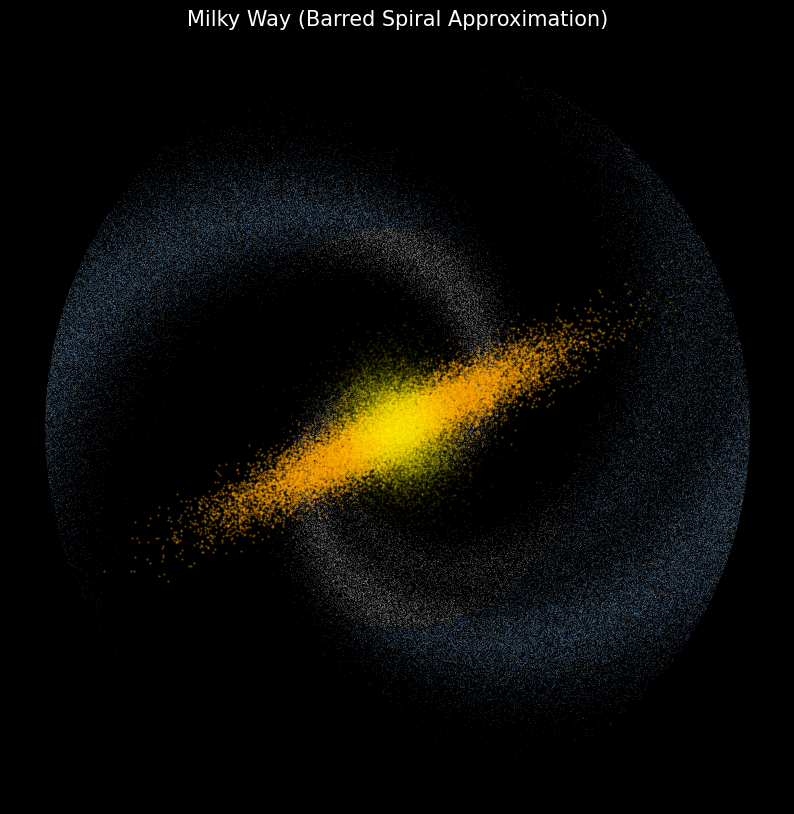

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# ----------------------------
# Parameters
# ----------------------------
n_stars = 140000
max_r = 15

# Arm definitions (2 main + 1 local spur)
arms = [
    {"phase": 0.0, "strength": 1.0},          # Scutum-Centaurus
    {"phase": np.pi, "strength": 1.0},       # Perseus (opposite side)
    {"phase": np.pi / 4, "strength": 0.4},   # Orion spur (weaker)
]

# ----------------------------
# Generate disk stars
# ----------------------------
r = np.random.power(2.2, n_stars) * max_r

arm_choice = np.random.choice(len(arms), size=n_stars, 
                             p=[a["strength"] for a in arms] / np.sum([a["strength"] for a in arms]))

theta = np.zeros(n_stars)

for i, arm in enumerate(arms):
    idx = arm_choice == i
    # Logarithmic spiral
    theta[idx] = arm["phase"] + np.log1p(r[idx]) * 2.2

# Add natural scatter
theta += np.random.normal(0, 0.25, n_stars)

x = r * np.cos(theta)
y = r * np.sin(theta)

# ----------------------------
# Add central bar
# ----------------------------
bar_n = 20000
bar_x = np.random.normal(0, 3.5, bar_n)
bar_y = np.random.normal(0, 0.6, bar_n)

# rotate bar slightly
angle = np.deg2rad(25)
bx = bar_x * np.cos(angle) - bar_y * np.sin(angle)
by = bar_x * np.sin(angle) + bar_y * np.cos(angle)

# ----------------------------
# Bulge (core)
# ----------------------------
bulge = np.random.normal(0, 1.2, (25000, 2))

# ----------------------------
# Color (radius-based)
# ----------------------------
colors = []
for radius in r:
    if radius < 3:
        colors.append((1.0, 0.85, 0.6))   # warm core
    elif radius < 8:
        colors.append((1.0, 1.0, 1.0))    # mid disk
    else:
        colors.append((0.6, 0.8, 1.0))    # outer disk

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 10), facecolor='black')

plt.scatter(x, y, s=0.15, c=colors, alpha=0.6, linewidths=0)
plt.scatter(bx, by, s=0.2, color='orange', alpha=0.5)      # bar
plt.scatter(bulge[:,0], bulge[:,1], s=0.3, color='yellow', alpha=0.08)

plt.gca().set_facecolor('black')
plt.axis('off')
plt.title("Milky Way (Barred Spiral Approximation)", color='white', fontsize=15)

plt.show()